<a href="https://colab.research.google.com/github/narendrapatel6321-dotcom/credit_card_fraud_detection/blob/main/credit_card_fraud_detection_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection — Data Preparation Pipeline

This notebook prepares the raw credit card transaction dataset for model training.

## Objectives

- Load and validate the raw dataset
- Perform exploratory data analysis (EDA)
- Analyse class imbalance
- Create stratified train/validation/test splits
- Apply leakage-safe feature engineering
- Export processed datasets for model training

### Outputs

- Processed train, validation, and test datasets
- Fitted feature transformer state

## Environment Setup

In [ ]:
# Mount Google Drive
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/CreditCardFraud")
PROCESSED_DIR = PROJECT_DIR / "processed"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
# Download dataset
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip -o creditcardfraud.zip -d data

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 102MB/s]

Archive:  creditcardfraud.zip
  inflating: data/creditcard.csv     


In [ ]:
# Clone repository
!git clone https://github.com/narendrapatel6321-dotcom/credit_card_fraud_detection.git
%cd credit_card_fraud_detection

Cloning into 'credit_card_fraud_detection'...
remote: Enumerating objects: 89, done.
remote: Counting objects: 100% (89/89), done.
remote: Compressing objects: 100% (86/86), done.
remote: Total 89 (delta 32), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (89/89), 55.39 KiB | 572.00 KiB/s, done.
Resolving deltas: 100% (32/32), done.
/content/credit_card_fraud_detection


In [ ]:
# Install project dependencies
!pip install -q -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 18.4 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.config import PipelineConfig
from src.data_pipeline import FraudDataLoader, ImbalanceAnalyzer
from src.feature_engineering import FraudFeatureTransformer
from src.model_trainer import FraudModelTrainer

plt.style.use("default")
pd.set_option("display.max_columns", None)

In [ ]:
# Pipeline configuration
config = PipelineConfig(
    DATA_PATH="/content/data/creditcard.csv",
)

## Load and Validate Dataset

Load the raw dataset, perform integrity checks, and inspect class imbalance.

In [ ]:
loader = FraudDataLoader(config)

df = loader.load()

print(f"Dataset shape : {df.shape}")
display(df.head())

Dataset shape : (283726, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.619995,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.690000,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.660004,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.500000,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798279,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.989998,0


In [ ]:
imbalance = ImbalanceAnalyzer(config)

imbalance_stats = imbalance.analyze(df)

print("Class Distribution")
for key, value in imbalance_stats.items():
    print(f"{key:25}: {value}")

Class Distribution
total_rows               : 283726
negative_count           : 283253
positive_count           : 473
negative_frequency       : 0.9983328986416472
positive_frequency       : 0.001667101358352777
imbalance_ratio          : 598.8435517970402
scale_pos_weight         : 598.8435517970402


## Exploratory Data Analysis

Understand the dataset characteristics before feature engineering.

In [ ]:
print(f"Dataset Shape : {df.shape}")
print(f"Features      : {df.shape[1] - 1}")
print(f"Fraud Cases   : {df['Class'].sum():,}")
print(f"Legitimate    : {(df['Class'] == 0).sum():,}")

display(df.head())
display(df.describe())

Dataset Shape : (283726, 31)
Features      : 30
Fraud Cases   : 473
Legitimate    : 283,253


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.619995,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.690000,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.660004,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.500000,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798279,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.989998,0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.085938,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,-0.001441,0.000202,-0.000715,0.000603,0.000252,0.001043,0.001162,0.000170,0.001515,-0.000264,0.000187,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47480.457031,1.947952,1.646582,1.508639,1.414147,1.376946,1.331881,1.227602,1.178902,1.095429,1.076329,1.018683,0.994619,0.995381,0.952175,0.914856,0.873660,0.842462,0.837337,0.813335,0.769908,0.723856,0.724537,0.623653,0.605583,0.521206,0.482042,0.395686,0.328003,250.354279,0.040796
min,0.000000,-56.407509,-72.715729,-48.325588,-5.683171,-113.743309,-26.160505,-43.557243,-73.216721,-13.434067,-24.588263,-4.797473,-18.683714,-5.791881,-19.214325,-4.498945,-14.129854,-25.162800,-9.498746,-7.213527,-54.497719,-34.830383,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565680,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,-0.535578,-0.761649,-0.406198,-0.647862,-0.425732,-0.581452,-0.466860,-0.483928,-0.498014,-0.456289,-0.211469,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,-0.093237,-0.032306,0.139072,-0.012927,0.050209,0.049299,0.067119,-0.065867,-0.002142,0.003367,-0.062353,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,0.453619,0.739579,0.616976,0.663178,0.492336,0.650104,0.523512,0.398972,0.501956,0.458508,0.133207,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510002,0.000000
max,172792.000000,2.454930,22.057730,9.382559,16.875343,34.801666,73.301628,120.589493,20.007208,15.594995,23.745136,12.018913,7.848392,7.126883,10.526766,8.877742,17.315111,9.253527,5.041069,5.591971,39.420906,27.202839,10.503090,22.528412,4.584549,7.519588,3.517346,31.612198,33.847809,25691.160156,1.000000


/tmp/ipykernel_2956/355613115.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Legitimate", "Fraud"])


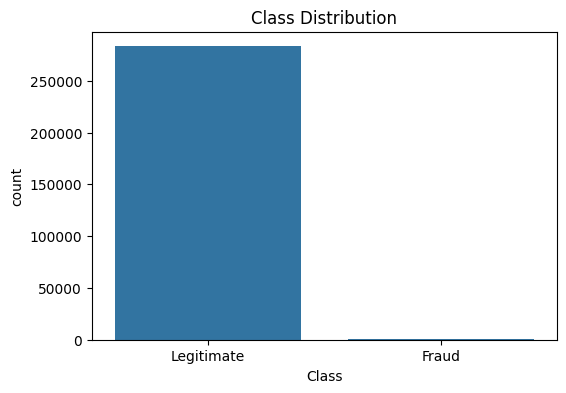

Fraud prevalence: 0.167%


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Class",
    ax=ax,
)

ax.set_xticklabels(["Legitimate", "Fraud"])
ax.set_title("Class Distribution")

plt.show()

fraud_rate = df["Class"].mean() * 100

print(f"Fraud prevalence: {fraud_rate:.3f}%")

### Transaction Amount

Transaction amounts are highly right-skewed. A logarithmic transformation is expected to reduce skewness and improve model learning.

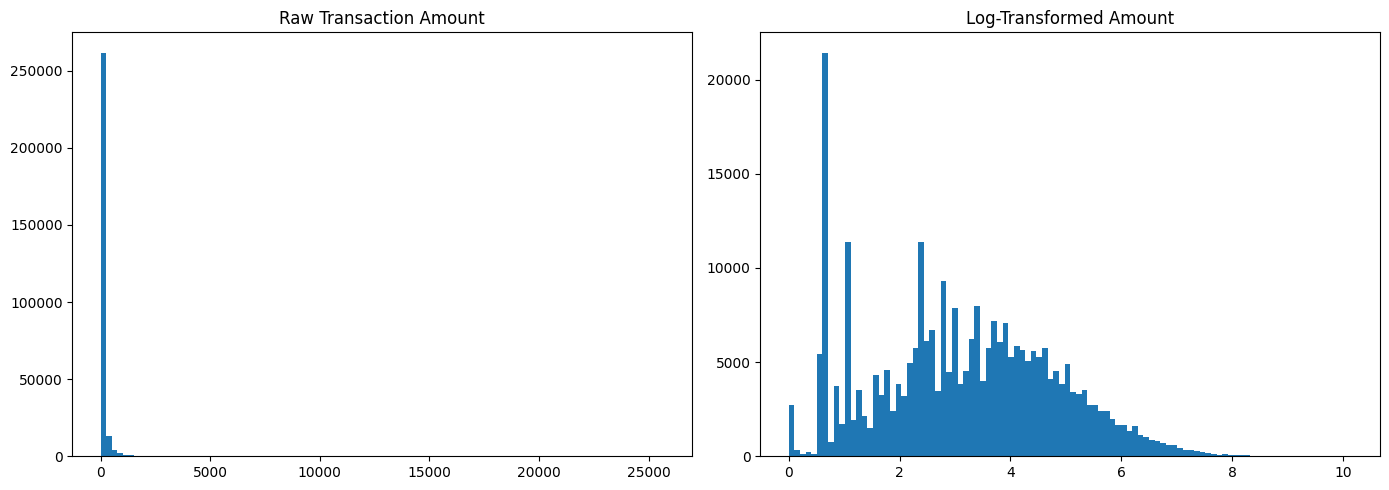

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["Amount"], bins=100)
axes[0].set_title("Raw Transaction Amount")

axes[1].hist(np.log1p(df["Amount"]), bins=100)
axes[1].set_title("Log-Transformed Amount")

plt.tight_layout()
plt.show()

### Transaction Time

The transaction time spans two days and exhibits a clear daily pattern. This motivates cyclical encoding using sine and cosine transformations.

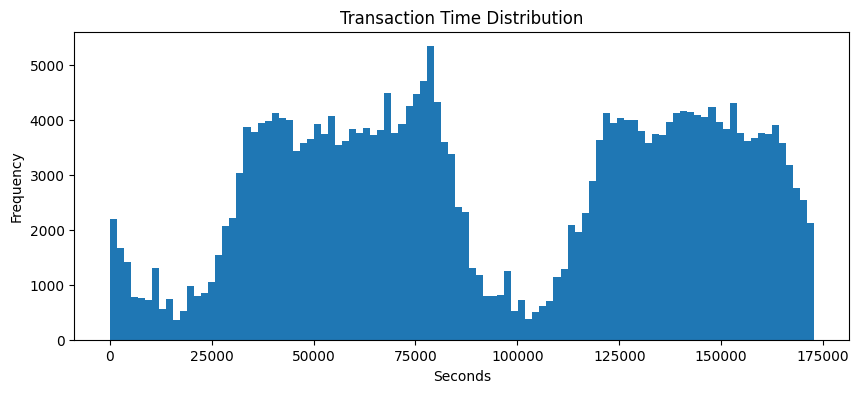

In [ ]:
plt.figure(figsize=(10,4))

plt.hist(df["Time"], bins=100)

plt.title("Transaction Time Distribution")
plt.xlabel("Seconds")
plt.ylabel("Frequency")

plt.show()

### Correlation Structure

The anonymised PCA features exhibit very low pairwise correlation, indicating that multicollinearity has largely been removed.

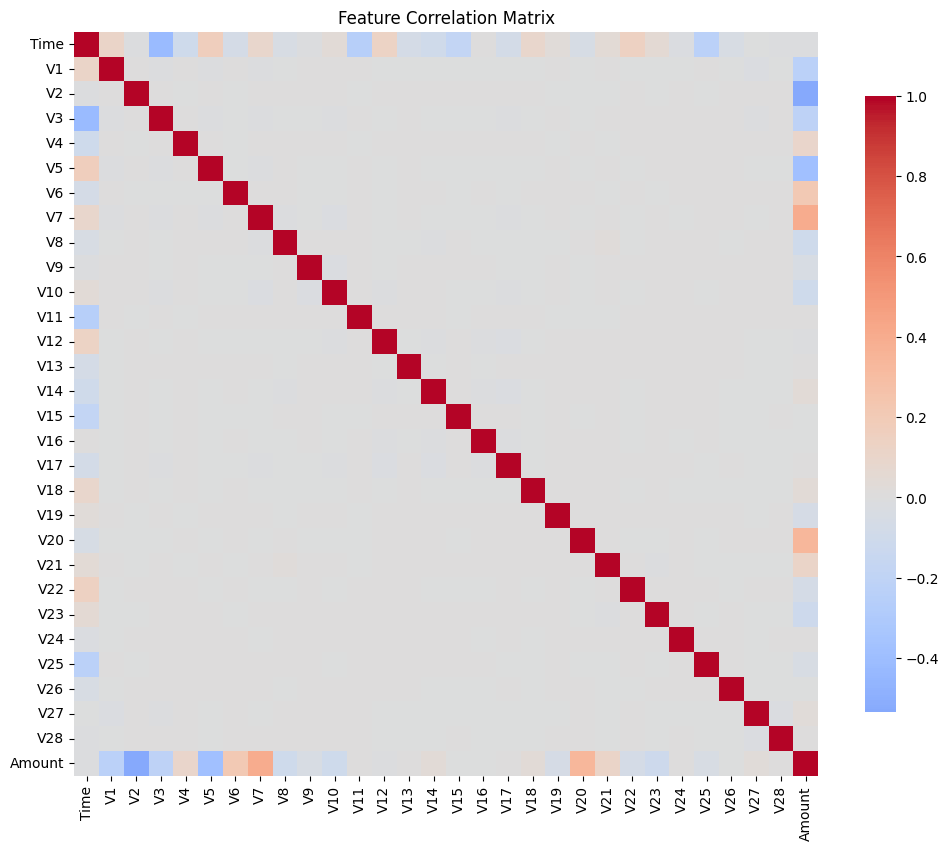

In [ ]:
corr = df.drop(columns="Class").corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8},
)

plt.title("Feature Correlation Matrix")

plt.show()

In [ ]:
corr_abs = corr.abs()

np.fill_diagonal(corr_abs.values, 0)

max_corr = corr_abs.max().max()

print(f"Maximum absolute pairwise correlation: {max_corr:.3f}")

Maximum absolute pairwise correlation: 0.533


### Key Observations

- The dataset is extremely imbalanced (~0.17% fraud).
- Transaction amounts are strongly right-skewed, motivating logarithmic transformation.
- Transaction timestamps exhibit daily periodicity, motivating cyclical time encoding.
- PCA-transformed features show minimal multicollinearity.

## Train / Validation / Test Split

The dataset is divided into stratified train, validation, and test sets to preserve the fraud prevalence across all partitions.

In [ ]:
trainer = FraudModelTrainer(config)

splits = trainer.split(df)

X_train = splits.X_train
X_val = splits.X_val
X_test = splits.X_test

y_train = splits.y_train
y_val = splits.y_val
y_test = splits.y_test

In [ ]:
split_summary = pd.DataFrame(
    {
        "Rows": [
            len(X_train),
            len(X_val),
            len(X_test),
        ],
        "Fraud Rate (%)": [
            y_train.mean() * 100,
            y_val.mean() * 100,
            y_test.mean() * 100,
        ],
    },
    index=["Train", "Validation", "Test"],
)

display(split_summary)

,Rows,Fraud Rate (%)
Train,198608,0.166660
Validation,42559,0.166827
Test,42559,0.166827


## Feature Engineering

The feature engineering pipeline learns preprocessing statistics from the training data and applies identical transformations to the validation and test sets to prevent data leakage.

In [ ]:
transformer = FraudFeatureTransformer(config)

X_train_eng = transformer.fit_transform(X_train)

X_val_eng = transformer.transform(X_val)

X_test_eng = transformer.transform(X_test)

In [ ]:
print("Original Features")
display(X_train.head())

print("\nEngineered Features")
display(X_train_eng.head())

Original Features


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
101639,68023.0,1.132089,0.194386,0.362150,0.588889,-0.271681,-0.398920,-0.099188,0.087250,-0.188893,-0.152785,1.970844,0.874799,-0.290774,0.027749,0.673683,0.342699,0.118127,-0.269962,-0.345081,-0.107427,-0.191899,-0.603157,0.165303,0.174239,0.068777,0.094035,-0.014924,0.020603,13.990000
63865,51034.0,-0.353027,-0.955101,1.715869,-1.862038,-1.993162,-0.171555,-0.058185,0.015741,-2.497221,0.997858,1.205402,-0.523280,0.400343,-0.379629,-0.071727,-0.060908,0.196679,0.980619,-0.134217,0.149578,0.186909,0.544119,0.334098,0.508283,-0.072215,-0.179250,0.007009,0.037677,200.000000
154640,104883.0,-0.646948,0.994754,2.041892,-0.318653,0.402454,0.073120,0.533261,-0.314370,1.680931,-0.920658,-0.325931,-2.783280,1.886013,1.115550,0.652530,-0.103787,0.026911,0.716029,0.806653,0.048154,-0.321418,-0.553597,-0.395771,-0.756263,0.332744,-0.713647,-0.353967,-0.151089,2.120000
192425,130004.0,-4.049534,-0.342911,-2.343460,-0.124219,2.275074,1.049156,1.202888,-0.393204,1.771429,1.124097,1.498819,0.069429,-0.633774,-2.853114,0.271748,-0.557232,1.693482,-0.150431,-0.091932,-1.399246,-0.642015,0.452424,0.251046,-1.079154,-0.377491,-0.347974,-0.903836,2.017586,93.769997
265838,162490.0,1.940494,-0.501533,0.047406,0.595139,-0.976805,-0.395403,-0.808078,0.030049,1.332178,0.017032,-1.038787,0.285470,0.164859,-0.283429,0.738337,0.671373,-0.709739,0.109722,-0.333920,-0.158223,0.023395,0.186586,0.283139,-0.102873,-0.526160,0.173262,0.004812,-0.032236,25.889999



Engineered Features


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Time_sin,Time_cos,Time_hour,Amount_log1p,Amount_is_round,Amount_scaled
101639,1.132089,0.194386,0.362150,0.588889,-0.271681,-0.398920,-0.099188,0.087250,-0.188893,-0.152785,1.970844,0.874799,-0.290774,0.027749,0.673683,0.342699,0.118127,-0.269962,-0.345081,-0.107427,-0.191899,-0.603157,0.165303,0.174239,0.068777,0.094035,-0.014924,0.020603,-0.972658,0.232243,18,2.707383,0,-0.111815
63865,-0.353027,-0.955101,1.715869,-1.862038,-1.993162,-0.171555,-0.058185,0.015741,-2.497221,0.997858,1.205402,-0.523280,0.400343,-0.379629,-0.071727,-0.060908,0.196679,0.980619,-0.134217,0.149578,0.186909,0.544119,0.334098,0.508283,-0.072215,-0.179250,0.007009,0.037677,-0.539383,-0.842060,14,5.303305,1,2.465482
154640,-0.646948,0.994754,2.041892,-0.318653,0.402454,0.073120,0.533261,-0.314370,1.680931,-0.920658,-0.325931,-2.783280,1.886013,1.115550,0.652530,-0.103787,0.026911,0.716029,0.806653,0.048154,-0.321418,-0.553597,-0.395771,-0.756263,0.332744,-0.713647,-0.353967,-0.151089,0.974419,0.224738,5,1.137833,0,-0.276283
192425,-4.049534,-0.342911,-2.343460,-0.124219,2.275074,1.049156,1.202888,-0.393204,1.771429,1.124097,1.498819,0.069429,-0.633774,-2.853114,0.271748,-0.557232,1.693482,-0.150431,-0.091932,-1.399246,-0.642015,0.452424,0.251046,-1.079154,-0.377491,-0.347974,-0.903836,2.017586,-0.029375,-0.999568,12,4.551453,0,0.993592
265838,1.940494,-0.501533,0.047406,0.595139,-0.976805,-0.395403,-0.808078,0.030049,1.332178,0.017032,-1.038787,0.285470,0.164859,-0.283429,0.738337,0.671373,-0.709739,0.109722,-0.333920,-0.158223,0.023395,0.186586,0.283139,-0.102873,-0.526160,0.173262,0.004812,-0.032236,-0.681466,0.731849,21,3.291754,0,0.053067


## Save Processed Datasets

Persist the processed datasets and fitted transformer for model training in Notebook 2.

In [ ]:
X_train_eng.to_csv(PROCESSED_DIR / "X_train.csv", index=False)

X_val_eng.to_csv(PROCESSED_DIR / "X_val.csv", index=False)

X_test_eng.to_csv(PROCESSED_DIR / "X_test.csv", index=False)

y_train.to_csv(PROCESSED_DIR / "y_train.csv", index=False)

y_val.to_csv(PROCESSED_DIR / "y_val.csv", index=False)

y_test.to_csv(PROCESSED_DIR / "y_test.csv", index=False)

In [ ]:
transformer.save_state(
    PROJECT_DIR / "artifacts" / "transformer_stats.json"
)

In [ ]:
print(f"Processed datasets saved to: {PROCESSED_DIR}")